# Laboratorio 7 - Etapa 1

Luis Ángel Girón


JuliánDivas

## Simulación básica con álbum reducido

Este notebook simula el llenado de un álbum de estampas con técnicas de Monte Carlo.
Se usa un álbum reducido para que la simulación sea rápida y repetible, y luego se compara
con la teoría del coleccionista.

## Objetivo

Estimar mediante simulación:

- el número esperado de sobres necesarios para completar la colección,
- el costo total esperado del proceso,
- la probabilidad de necesitar más de 30 sobres,
- y el efecto de las estampas repetidas.

## Parámetros de la simulación

- Número total de estampas distintas: `N = 100`
- Estampas por sobre: `S = 7`
- Número de simulaciones: `R = 10000`
- Semilla aleatoria: `2026`

Cada sobre contiene 7 estampas distintas, elegidas sin reemplazo dentro del mismo sobre.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(2026)

N = 100
S = 7
R = 10000

def simular_album(n_estampas: int, estampas_por_sobre: int):
    vistas = np.zeros(n_estampas, dtype=bool)
    sobres = 0
    repetidas = 0

    while not np.all(vistas):
        paquete = np.random.choice(n_estampas, size=estampas_por_sobre, replace=False)
        sobres += 1
        repetidas += int(np.sum(vistas[paquete]))
        vistas[paquete] = True

    return sobres, repetidas

sobres_necesarios = np.empty(R, dtype=int)
repetidas_acumuladas = np.empty(R, dtype=int)

for i in range(R):
    sobres_necesarios[i], repetidas_acumuladas[i] = simular_album(N, S)

media_sobres = np.mean(sobres_necesarios)
desv_sobres = np.std(sobres_necesarios, ddof=1)
media_repetidas = np.mean(repetidas_acumuladas)
desv_repetidas = np.std(repetidas_acumuladas, ddof=1)
prob_mas_30 = np.mean(sobres_necesarios > 30)

minimo_teorico = int(np.ceil(N / S))
minimo_observado = np.min(sobres_necesarios)
casos_minimo = np.sum(sobres_necesarios == minimo_teorico)
H_N = np.sum(1 / np.arange(1, N + 1))
esperado_teorico = (N / S) * H_N
esperado_repetidas_teorico = S * esperado_teorico - N
diferencia_sobres = media_sobres - esperado_teorico
diferencia_repetidas = media_repetidas - esperado_repetidas_teorico
coef_variacion_sobres = desv_sobres / media_sobres
costo_sobre_individual = 9.50
costo_caja_104 = 975.00
costo_esperado_sobres = media_sobres * costo_sobre_individual

print(f'Parámetros: N={N}, S={S}, R={R}, semilla=2026')
print(f'Mínimo teórico de sobres sin repetidas: {minimo_teorico}')
print(f'Mínimo observado en la simulación: {minimo_observado}')
print(f'Casos observados con el mínimo teórico: {casos_minimo}')
print(f'Media simulada de sobres necesarios: {media_sobres:.4f}')
print(f'Desviación estándar de sobres necesarios: {desv_sobres:.4f}')
print(f'Media simulada de estampas repetidas: {media_repetidas:.4f}')
print(f'Desviación estándar de estampas repetidas: {desv_repetidas:.4f}')
print(f'Probabilidad de necesitar más de 30 sobres: {prob_mas_30:.4f}')
print(f'H_100 exacto: {H_N:.4f}')
print(f'Esperanza teórica aproximada de sobres: {esperado_teorico:.4f}')
print(f'Diferencia media simulada - teoría en sobres: {diferencia_sobres:.4f}')
print(f'Esperanza teórica de estampas repetidas: {esperado_repetidas_teorico:.4f}')
print(f'Diferencia media simulada - teoría en repetidas: {diferencia_repetidas:.4f}')
print(f'Coeficiente de variación de sobres: {coef_variacion_sobres:.4f}')
print(f'Costo esperado aproximado comprando sobres individuales: Q{costo_esperado_sobres:.2f}')
print(f'Costo de una caja de 104 sobres: Q{costo_caja_104:.2f}')

Parámetros: N=100, S=7, R=10000, semilla=2026
Mínimo teórico de sobres sin repetidas: 15
Mínimo observado en la simulación: 37
Casos observados con el mínimo teórico: 0
Media simulada de sobres necesarios: 72.2456
Desviación estándar de sobres necesarios: 17.4724
Media simulada de estampas repetidas: 405.7192
Desviación estándar de estampas repetidas: 122.3067
Probabilidad de necesitar más de 30 sobres: 1.0000
H_100 exacto: 5.1874
Esperanza teórica aproximada de sobres: 74.1054
Diferencia media simulada - teoría en sobres: -1.8598
Esperanza teórica de estampas repetidas: 418.7378
Diferencia media simulada - teoría en repetidas: -13.0186
Coeficiente de variación de sobres: 0.2418
Costo esperado aproximado comprando sobres individuales: Q686.33
Costo de una caja de 104 sobres: Q975.00


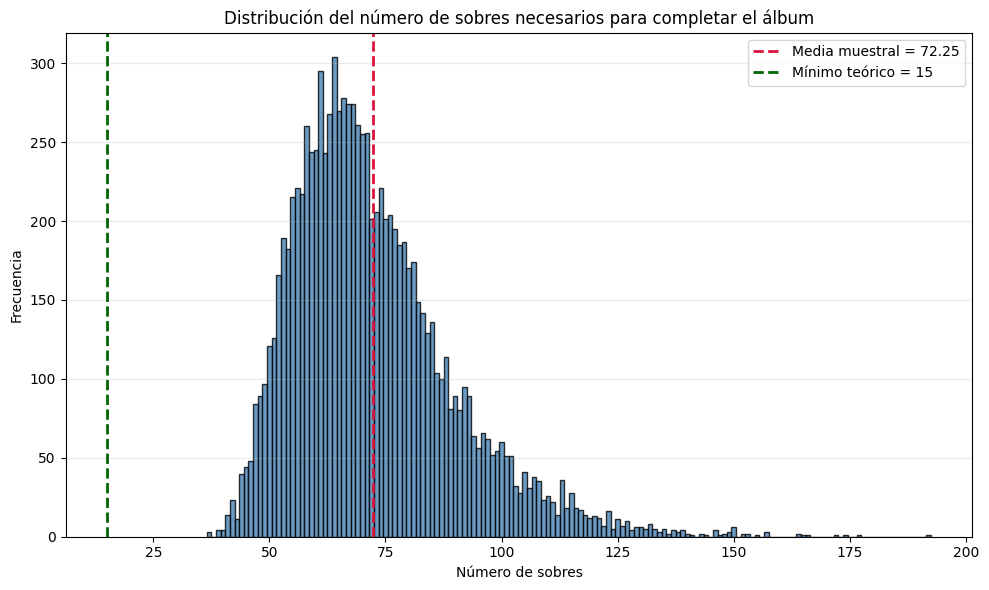

In [2]:
plt.figure(figsize=(10, 6))
bins = np.arange(sobres_necesarios.min() - 0.5, sobres_necesarios.max() + 1.5, 1)
plt.hist(sobres_necesarios, bins=bins, color='steelblue', edgecolor='black', alpha=0.8)
plt.axvline(media_sobres, color='crimson', linestyle='--', linewidth=2, label=f'Media muestral = {media_sobres:.2f}')
plt.axvline(minimo_teorico, color='darkgreen', linestyle='--', linewidth=2, label=f'Mínimo teórico = {minimo_teorico}')
plt.title('Distribución del número de sobres necesarios para completar el álbum')
plt.xlabel('Número de sobres')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## Preguntas de análisis

**Justificación del umbral de 30 sobres:** el mínimo absoluto sin repetidas es `ceil(100 / 7) = 15` sobres, porque con 14 sobres solo se podrían obtener `14 * 7 = 98` estampas. Por eso, 30 sobres representa el doble del mínimo teórico. En la simulación, la probabilidad de necesitar más de 30 sobres fue `1.0000`, es decir, todas las simulaciones necesitaron más de 30 sobres.

1. El número mínimo de sobres si no hubiera estampas repetidas en todo el proceso sería `ceil(100 / 7) = 15`. En las `10000` simulaciones no se observó ningún caso con 15 sobres; de hecho, el mínimo observado fue de 37 sobres. Esto muestra que el mínimo teórico es solo una cota ideal y no un resultado probable bajo muestreo aleatorio.

2. Para `N = 100`, el valor exacto usado en el notebook es `H_100 = 5.1874`. Entonces, la predicción del coleccionista para sobres de `S = 7` estampas es `(100 / 7) * 5.1874 = 74.1054` sobres. La media simulada fue `72.2456` sobres, una diferencia de `-1.8598` sobres respecto al valor teórico aproximado, por lo que la simulación es razonablemente cercana.

3. Como al terminar el álbum hay exactamente `N = 100` estampas distintas, las repetidas esperadas se pueden estimar como `S * E[sobres] - N`. Con la teoría: `7 * 74.1054 - 100 = 418.7378` estampas repetidas. La media simulada fue `405.7192`, con una diferencia de `-13.0186` repetidas. La diferencia es aceptable porque la fórmula de sobres es una aproximación y las simulaciones tienen variabilidad.

4. La desviación estándar de sobres fue `17.4724`, que equivale a un coeficiente de variación de aproximadamente `0.2418` o `24.18%` de la media. Es una variabilidad alta porque al inicio casi cada sobre aporta estampas nuevas, pero al final faltan pocas estampas y la probabilidad de conseguir justo esas estampas baja mucho. Eso genera una distribución con cola derecha: algunas simulaciones terminan relativamente rápido y otras tardan muchos sobres más.